In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from run_models import run_VAE
from utils.common import extract_latents_with_names, combine_audio_and_lyrics
from datasets import AudioSpectogramGenreDataset

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch, numpy as np, shutil, pandas as pd
from pathlib import Path

1. Create the new dataset
2. Conditional VAE = Convolutional VAE w supervised dataset???
3. Which functions are reusable??
4. Overall workflow???

In [4]:
from run_models import run_VAE, run_PCA, run_KMeans
from tuning import run_tuning
from utils.common import extract_latents

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
root = Path("../..")

In [23]:
cvae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="cvae", root=root) #type: ignore

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-09 16:27:41,735] A new study created in memory with name: Conditional VAE Tuning





[2 0 6 3 1 4 5 8 7 9]






{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}





  0%|          | 0/2 [00:00<?, ?it/s]D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([32, 1, 64, 91])) that is different to the input size (torch.Size([32, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([3, 1, 64, 91])) that is different to the input size (torch.Size([3, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([9, 1, 64, 91])) that is different to the input size (torch.Size([9, 64, 91])). This will likely lead to incorrect res

--------------------------------------------------
Epoch 1 / 1
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 10458.0993   | 5296.6940   
Recon        | 10450.0355   | 5287.6839   
KL Div       | 80.6381      | 90.1009     
--------------------------------------------------

[I 2026-04-09 16:27:43,569] Trial 0 finished with value: 3208.6507160959072 and parameters: {'HIDDEN_DIM_1': 1024, 'HIDDEN_DIM_2': 128, 'LATENT_DIM': 32, 'LR': 0.0005105903209394755, 'BATCH_SIZE': 32, 'BETA': 5.0}. Best is trial 0 with value: 3208.6507160959072.


Best trial: 0. Best value: 3208.65:  50%|█████     | 1/2 [00:02<00:02,  2.08s/it]D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([64, 1, 64, 91])) that is different to the input size (torch.Size([64, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([35, 1, 64, 91])) that is different to the input size (torch.Size([35, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([41, 1, 64, 91])) that is different to the input size (torch.Size([41, 6

--------------------------------------------------
Epoch 1 / 1
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 25095.5431   | 9050.6808   
Recon        | 25092.5353   | 9046.7895   
KL Div       | 30.0790      | 38.9129     
--------------------------------------------------

[I 2026-04-09 16:27:45,818] Trial 1 finished with value: 5443.638858999552 and parameters: {'HIDDEN_DIM_1': 2048, 'HIDDEN_DIM_2': 512, 'LATENT_DIM': 32, 'LR': 0.00032676417657817656, 'BATCH_SIZE': 64, 'BETA': 4.0}. Best is trial 0 with value: 3208.6507160959072.


Best trial: 0. Best value: 3208.65: 100%|██████████| 2/2 [00:04<00:00,  2.17s/it]
[W 2026-04-09 16:27:46,167] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,168] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,168] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,169] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,169] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,170] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,170] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,170] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,171] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 16:27:46,171] Param LATENT_DIM unique value length is less than 2.


Saved: results\trials\plots\cvae\optimization_history.html
Saved: results\trials\plots\cvae\param_importances.html
Saved: results\trials\plots\cvae\parallel_coordinate.html
Saved: results\trials\plots\cvae\edf.html
Saved: results\trials\plots\cvae\timeline.html
Saved: results\trials\plots\cvae\contour.html
Best trial for `cvae`:
Score: 3208.6507
    HIDDEN_DIM_1              1024
    HIDDEN_DIM_2              128
    LATENT_DIM                32
    LR                        0.0005105903209394755
    BATCH_SIZE                32
    BETA                      5.0


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=5834, out_features=1024, bias=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Linear(in_features=1024, out_features=128, bias=True)
      (4): LeakyReLU(negative_slope=0.01, inplace=True)
    )
    (mu_layer): Linear(in_features=128, out_features=32, bias=True)
    

D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([32, 1, 64, 91])) that is different to the input size (torch.Size([32, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([3, 1, 64, 91])) that is different to the input size (torch.Size([3, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([9, 1, 64, 91])) that is different to the input size (torch.Size([9, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensu

--------------------------------------------------
Epoch 1 / 1
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 13625.9913   | 4517.4846   
Recon        | 13618.7858   | 4512.1310   
KL Div       | 72.0548      | 53.5356     
--------------------------------------------------



In [24]:
pca_baseline, pca_history = run_PCA(n_components=latent_dim, train_loader=train_loader, test_loader=test_loader)

In [25]:
train_latents, train_labels = extract_latents(model=cvae, loader=train_loader, device=device)
test_latents,  test_labels  = extract_latents(model=cvae, loader=test_loader,  device=device)

In [26]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)
vae_labels  = np.concatenate([train_labels,  test_labels],  axis=0)

In [27]:
set(list(vae_labels))

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)}

In [28]:
pca_latents = np.concatenate([
        pca_baseline.transform(train_loader),
        pca_baseline.transform(test_loader)
    ])

In [29]:
vae_kmeans, vae_metrics = run_KMeans(vae_latents, model_type="cvae")

True



Optimal k        : 5
Inertia (WCSS)   : 372.8063
Silhouette Score : 0.3724
CH Index         : 2454.4347





<Figure size 800x550 with 0 Axes>

In [30]:
pca_kmeans, pca_metrics = run_KMeans(pca_latents, model_type="pca")

True



Optimal k        : 5
Inertia (WCSS)   : 107380.0000
Silhouette Score : 0.2282
CH Index         : 680.0058





<Figure size 800x550 with 0 Axes>

In [31]:
from collections import Counter

for cluster_id in range(5):
    mask = vae_kmeans.labels_ == cluster_id
    genre_counts = Counter(vae_labels[mask])
    print(f"Cluster {cluster_id}: {genre_counts}")

Cluster 0: Counter({np.int64(0): 217, np.int64(4): 74, np.int64(2): 53, np.int64(3): 53, np.int64(1): 39, np.int64(8): 22, np.int64(7): 22, np.int64(5): 20, np.int64(6): 15, np.int64(9): 2})
Cluster 1: Counter({np.int64(0): 558, np.int64(1): 42, np.int64(3): 34, np.int64(2): 15, np.int64(7): 14, np.int64(5): 11, np.int64(4): 7, np.int64(9): 5, np.int64(6): 5, np.int64(8): 3})
Cluster 2: Counter({np.int64(0): 67, np.int64(4): 34, np.int64(2): 23, np.int64(3): 20, np.int64(5): 10, np.int64(8): 10, np.int64(7): 6, np.int64(6): 4, np.int64(1): 4, np.int64(9): 1})
Cluster 3: Counter({np.int64(0): 437, np.int64(4): 62, np.int64(3): 56, np.int64(1): 42, np.int64(5): 28, np.int64(2): 21, np.int64(8): 8, np.int64(6): 7, np.int64(7): 5, np.int64(9): 2})
Cluster 4: Counter({np.int64(0): 155, np.int64(2): 69, np.int64(1): 69, np.int64(6): 30, np.int64(3): 21, np.int64(7): 18, np.int64(8): 9, np.int64(4): 6, np.int64(9): 5, np.int64(5): 4})


In [32]:
from visualizations import plot_tsne_pca_vs_vae

Computing t-SNE for PCA features...
Computing t-SNE for VAE features...
Saved → ..\..\results\clustering\tsne_pca_vs_vae.png


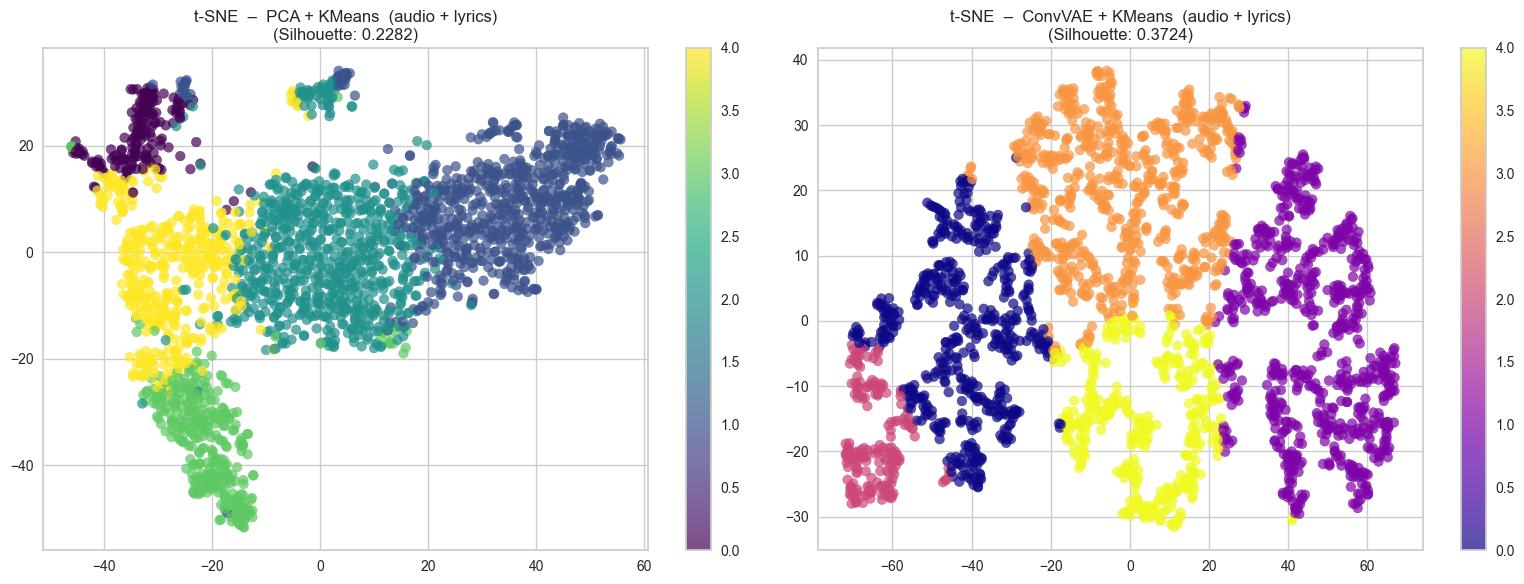

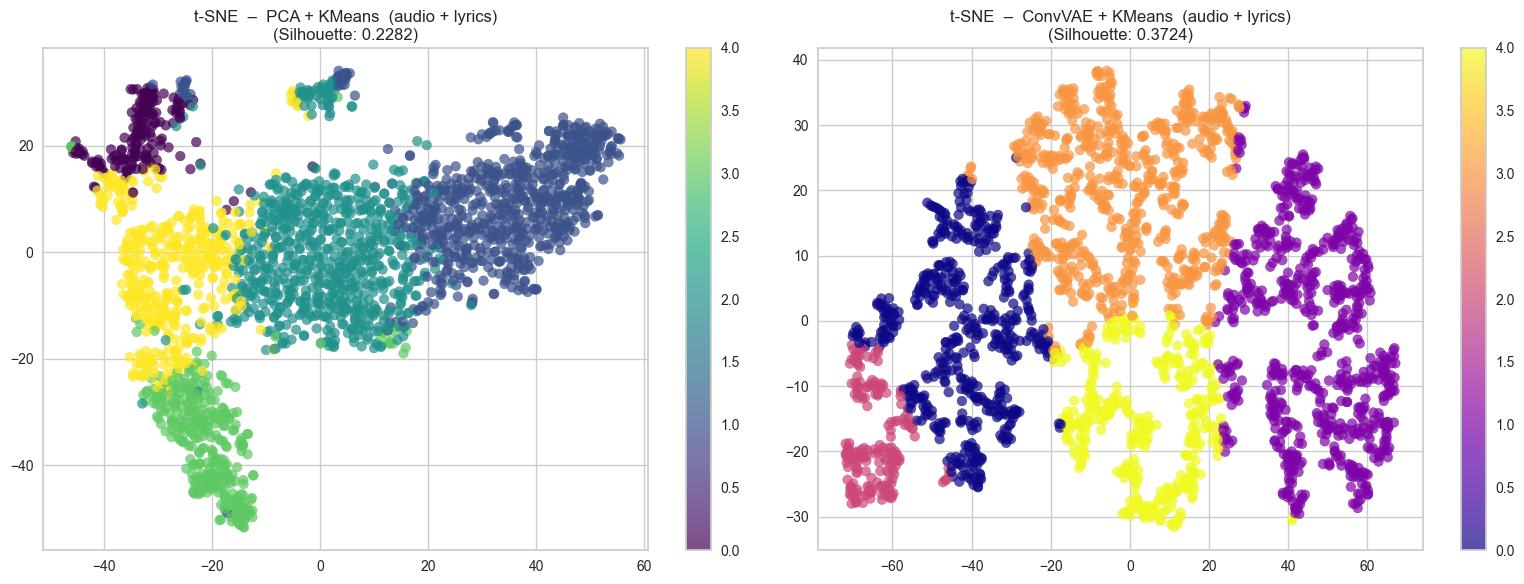

In [33]:
plot_tsne_pca_vs_vae(
    pca_latents  = pca_latents,
    vae_latents  = vae_latents,
    pca_clusters = pca_kmeans.labels_,
    vae_clusters = vae_kmeans.labels_,
    pca_sil      = pca_metrics["silhouette"],
    vae_sil      = vae_metrics["silhouette"],
    save_path    = root / config.RESULT_DIR / "clustering" / "tsne_pca_vs_vae.png"
)